In [33]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

In [34]:
# Step 1: Initialize a 4-qubit circuit with |0010⟩ state
qc = QuantumCircuit(5)

# Set the initial state: |0010⟩
qc.x(1)

qc.barrier(range(5))

In [35]:
for qubit in range(4,-1,-1):
    # Apply Hadamard to the current qubit
    qc.h(qubit)
    
    # Apply controlled rotations (R_k) on subsequent qubits
    for k in range(qubit):
        angle = 2 * np.pi / (2 ** (k + 2))
        qc.cp(angle, qubit - k -1, qubit)   # .cp is the controlled phase gate
    qc.barrier(range(5))
for i in range(5 // 2):
        qc.swap(i, 5 - 1 - i)

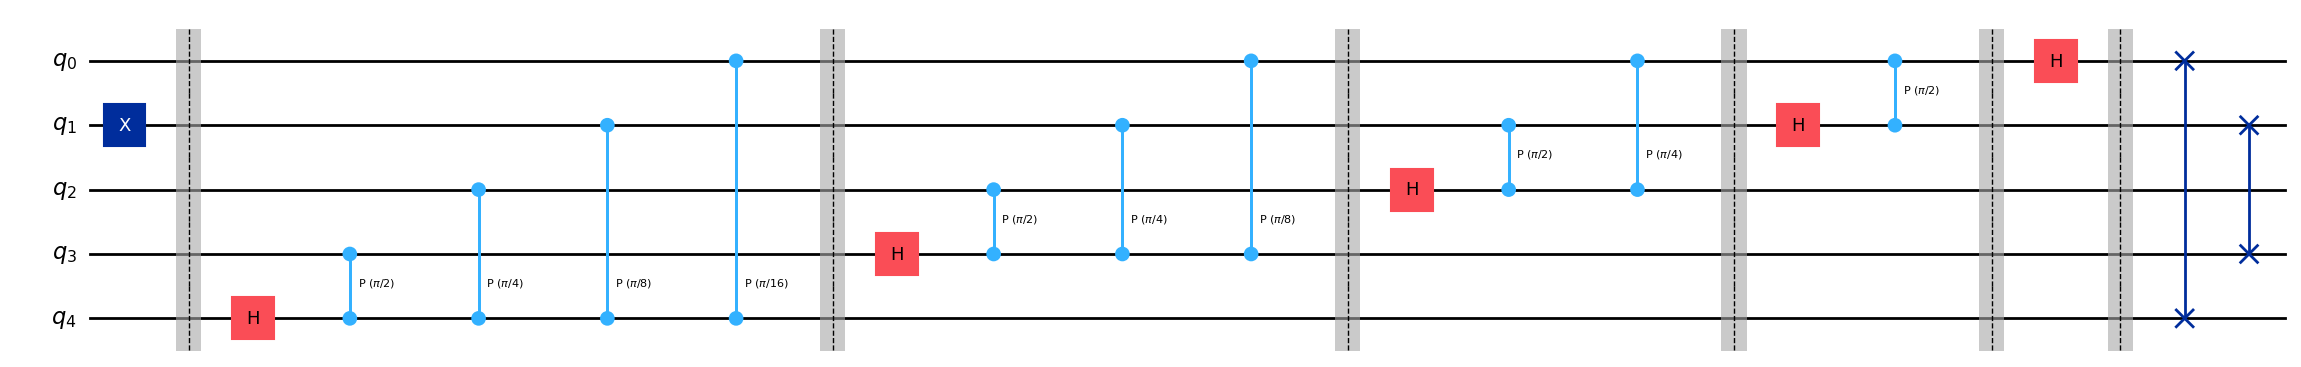

In [36]:
qc.draw('mpl', fold=-1)

In [37]:
from qiskit.quantum_info import Statevector

# Set the initial state of the simulator to the ground state using from_int
state = Statevector.from_int(0, 2**5)

# Evolve the state by the quantum circuit
state = state.evolve(qc)

#draw using latex
state.draw('latex')

<IPython.core.display.Latex object>

In [38]:
# Step 3: Measure all qubits
qc.measure_all()

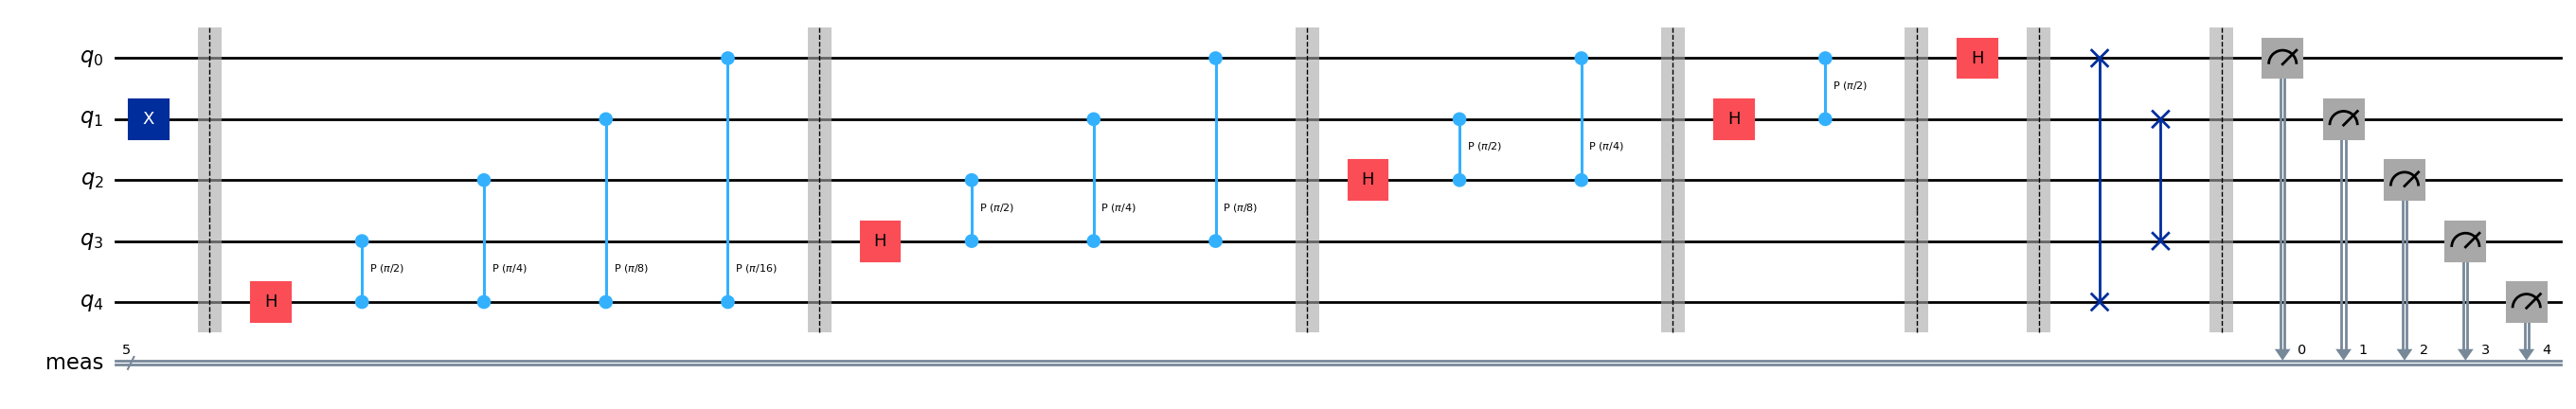

In [39]:
qc.draw('mpl', fold=-1)

In [40]:
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

In [41]:
result = simulator.run(compiled_circuit, shots=9600).result()

Measurement counts: {'10010': 301, '01100': 301, '00010': 312, '11100': 290, '00100': 291, '00000': 290, '00110': 293, '00101': 339, '10000': 296, '01010': 290, '10110': 304, '10011': 318, '10001': 269, '01000': 276, '00001': 307, '01011': 287, '00111': 314, '11101': 301, '10100': 280, '11000': 294, '11111': 294, '01001': 321, '00011': 283, '11110': 298, '11011': 308, '01111': 325, '11010': 296, '01101': 303, '10111': 325, '01110': 319, '10101': 292, '11001': 283}


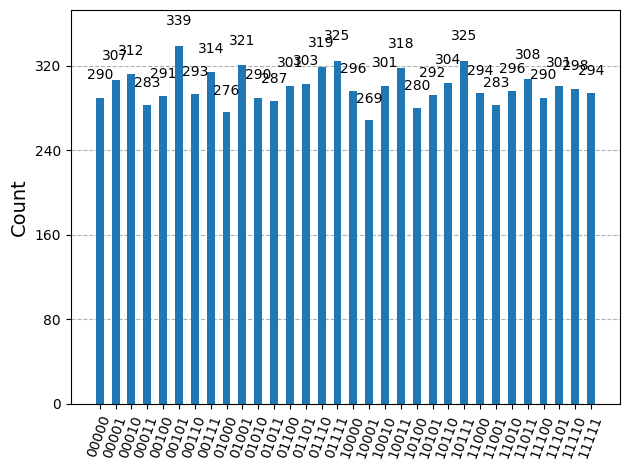

In [42]:
# Get and plot counts
counts = result.get_counts()
print("Measurement counts:", counts)
plot_histogram(counts)

In [43]:
from qiskit.circuit.library import QFT

In [44]:
qft_circ = QFT(5, inverse=False)

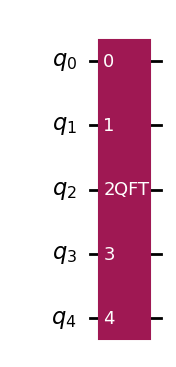

In [45]:
qft_circ.draw('mpl')

In [46]:
qft = QuantumCircuit(5)

qft.x(1)

qft = qft.compose(qft_circ)

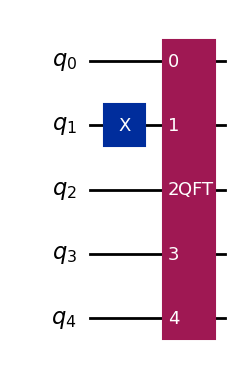

In [47]:
qft.draw('mpl')

In [48]:
# Set the initial state of the simulator to the ground state using from_int
state = Statevector.from_int(0, 2**5)

# Evolve the state by the quantum circuit
state = state.evolve(qft)

#draw using latex
state.draw('latex')

<IPython.core.display.Latex object>

This matches our previous answer. Now let's do the same for $e^{2ix}$

In [49]:
# Step 1: Discretize e^(2ix) into 2^4 = 16 points
n_qubits = 5
num_points = 2**n_qubits
x = np.linspace(0, 2*np.pi, num_points, endpoint=False)
func_values = np.exp(1j*2*x) + np.exp(1j*4*x)

# Normalize the values to fit as amplitudes
normalized_values = func_values / np.linalg.norm(func_values)

In [50]:
# Step 2: Encode the normalized values into a quantum state
qc_exp = QuantumCircuit(n_qubits)
qc_exp.initialize(normalized_values, range(n_qubits))

In [51]:
qft_circ_inv = QFT(5, inverse=True)

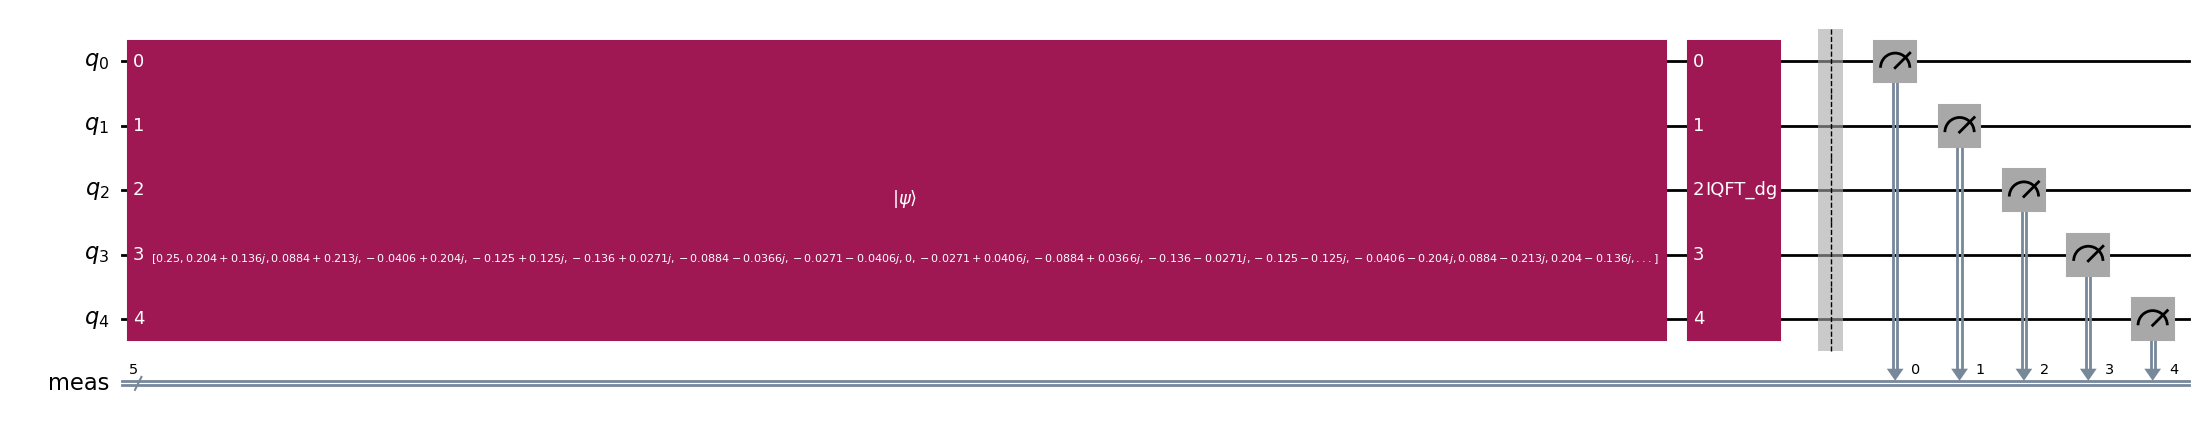

In [52]:
qc_exp.compose(qft_circ_inv, inplace=True)
qc_exp.measure_all()
qc_exp.draw('mpl', fold=-1)

In [53]:
qc_exp_comp = transpile(qc_exp, simulator)

In [54]:
result = simulator.run(qc_exp_comp, shots=9600).result()

Measurement counts: {'00100': 4760, '00010': 4840}


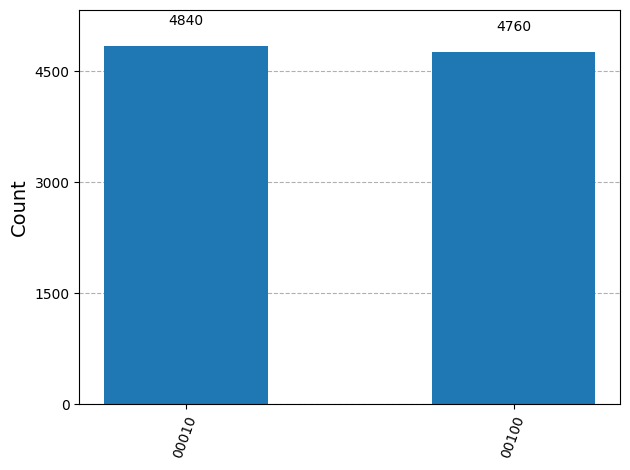

In [55]:
# Get and plot counts
counts = result.get_counts()
print("Measurement counts:", counts)
plot_histogram(counts)

True θ = 2.75
Raw counts: {'1011': 9600}
Measured bitstring: 1011
Estimated θ = 2.75


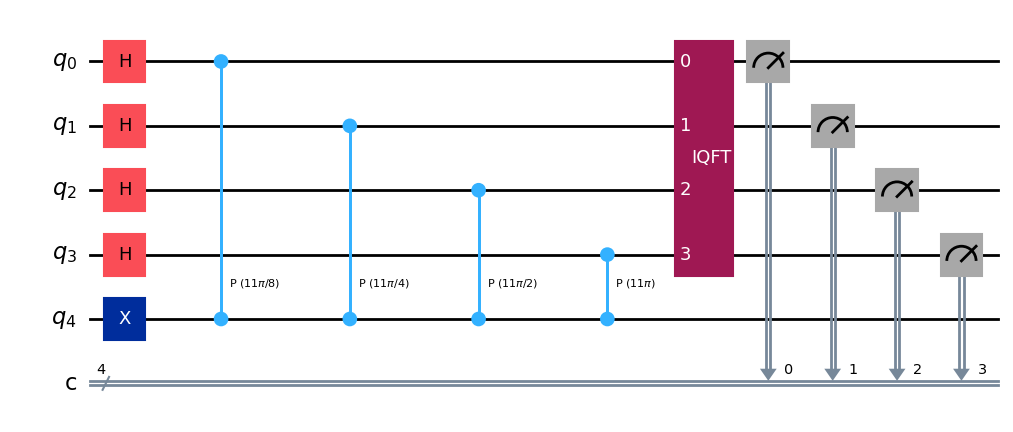

In [63]:
import numpy as np
import base64
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator

# ──────────────────────────────────────────────
# 1) Load θ (true value < 4)
with open("theta.txt", "r") as f:
    theta = float(base64.b64decode(f.read()).decode())
print("True θ =", theta)

# 2) Number of counting qubits
t = 4   # 4 bits of precision: resolution = 1/16

# 3) Build the QPE circuit
qc = QuantumCircuit(t+1, t)

# 3a) Put counting register into superposition
qc.h(range(t))

# 3b) Prepare eigenstate |1⟩ in the bottom qubit
qc.x(t)

# 3c) Apply controlled-U^(2^j) with U = e^{2πi·(θ/4)}
for j in range(t):
    phi = theta / 4
    angle = 2 * np.pi * phi * (2**j)   # this is the only place θ/4 enters
    qc.cp(angle, j, t)

# 3d) Inverse QFT (with built‑in swaps)
qc.append(QFT(t, inverse=True), range(t))

# 3e) Measure all counting qubits (no manual swaps!)
qc.measure(range(t), range(t))

# 4) Simulate
sim = AerSimulator()
qc_comp = transpile(qc, sim)
counts = sim.run(qc_comp, shots=9600).result().get_counts()
print("Raw counts:", counts)

# 5) Decode result
bitstr = max(counts, key=counts.get)        # e.g. '1011'
phi_est = int(bitstr, 2) / 2**t             # φ_est ≈ θ/4
theta_est = phi_est * 4                     # recover θ
print(f"Measured bitstring: {bitstr}")
print(f"Estimated θ = {theta_est}")

qc.draw('mpl', fold=-1)
